In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt``
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

In [36]:
def plot_samples(trace, gabors, orientations):
    # share x only for 1st row of subplots
    fig, axs = plt.subplots(nrows=12, ncols=8, dpi=400) #, sharex="row", sharey="row")
    for idx, ax in enumerate(axs[::2].ravel()):
        response = trace["neuron"][:, idx]
        response_mean = np.mean(trace['neuron'][:, idx].ravel())
        color = "blue" if response_mean < 0.3 else "red"
        sns.histplot(response.ravel(), color=color, stat="probability", element="step", ax=ax)
        ax.text(0.05, 0.95, idx+1, fontsize=4, transform=ax.transAxes)
        ax.text(0.5, 0.95, f"{response_mean:.2f}", fontsize=4, transform=ax.transAxes)
        ax.text(0.95, 0.95, f"{int(np.rad2deg(orientations[idx]))}$^\circ$", fontsize=4, transform=ax.transAxes)
        ax.tick_params(axis='both', which='major', labelsize=5)
        # reduce the font size of the x and y labels
        ax.axis("off")
        # ax.xaxis.label.set_size(5)
        # ax.yaxis.label.set_size(5)
    for idx, ax in enumerate(axs[1::2].ravel()):
        ax.imshow(gabors[idx], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
        

In [8]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : [0., np.pi/4, np.pi/3, np.pi/2, 2*np.pi/3, 3*np.pi/4, 5*np.pi/4, 4*np.pi/3],  
    "phases"              : [np.pi/2, 0.],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)

In [9]:
len(gabor_set.images())

48

In [27]:
fig, axs = plt.subplots(nrows=12, ncols=8, dpi=400)
axs.shape

(12, 8)

Error in callback <function flush_figures at 0x7f430c213550> (for post_execute):


KeyboardInterrupt: 

In [30]:
axs[::2].ravel().shape

(48,)

In [33]:
axs[1::2].ravel().shape

(48,)

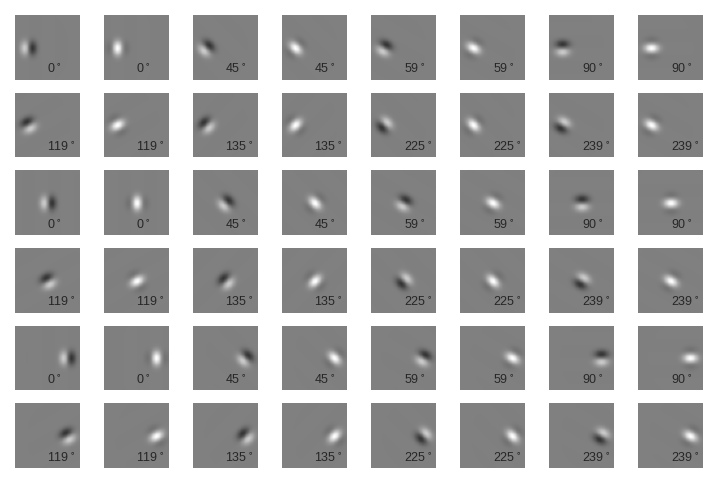

In [10]:
fig, axs = plt.subplots(6, 8, dpi=150)
for i, ax in enumerate(axs.flatten()):
    image = gabor_set.images()[i]
    orientation = gabor_set.params_dict_from_idx(i)["orientation"]
    ax.imshow(image, cmap="gray", vmin=-1, vmax=1)
    ax.text(0.5, 0.1, f"{int(np.rad2deg(orientation))}$^\circ$", transform=ax.transAxes, fontsize=6)
    ax.axis("off")

In [12]:
orientations = np.array([gabor_set.params_dict_from_idx(i)["orientation"] for i in range(len(gabor_set.images()))])

In [11]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

In [52]:
def sample_posterior(stimulus, vonmises_kappa=5., n_samples=1000):
    vonmises_loc = 0.
    n_neurons = len(gabor_set.images())
    stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        o = pm.Uniform("orientation", lower=-np.pi/2, upper=np.pi/2)
        z = pm.Exponential(
            "neuron", 
            lam=vonmises_pdf(o - orientations, vonmises_loc, vonmises_kappa),
            shape=n_neurons
        )
        x = pm.Normal("stimulus", mu=torch.tensor(gabor_set.images()).permute(1, 2, 0) @ z, sigma=stimulus_sigma, observed=stimulus)
        trace = pm.sample(n_samples, return_inferencedata=False)
    return trace

(-0.5, 49.5, 49.5, -0.5)

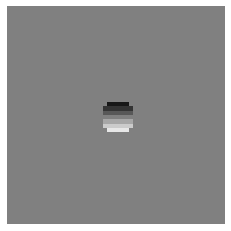

In [14]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1/20],
    "spatial_frequencies_surround": [1/10],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0.],
}

circle_center_PF = CenterSurround(**center_surround_params).images()[0]
plt.imshow(circle_center_PF, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")


In [53]:
circle_center_trace = sample_posterior(circle_center_PF, vonmises_kappa=2., n_samples=1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 148 seconds.
There were 760 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5095788919605803, but should be close to 0.8. Try to increase the number of tuning steps.
There were 734 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5362121042903228, but should be close to 0.8. Try to increase the number of tuning steps.
There were 587 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6925262952559256, but should be close to 0.8. Try to increase the number of tuning steps.
There were 490 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.4 for some parameters. The sampler did not converge.
The estima

In [54]:
circle_center_trace["neuron"].shape

(4000, 48)

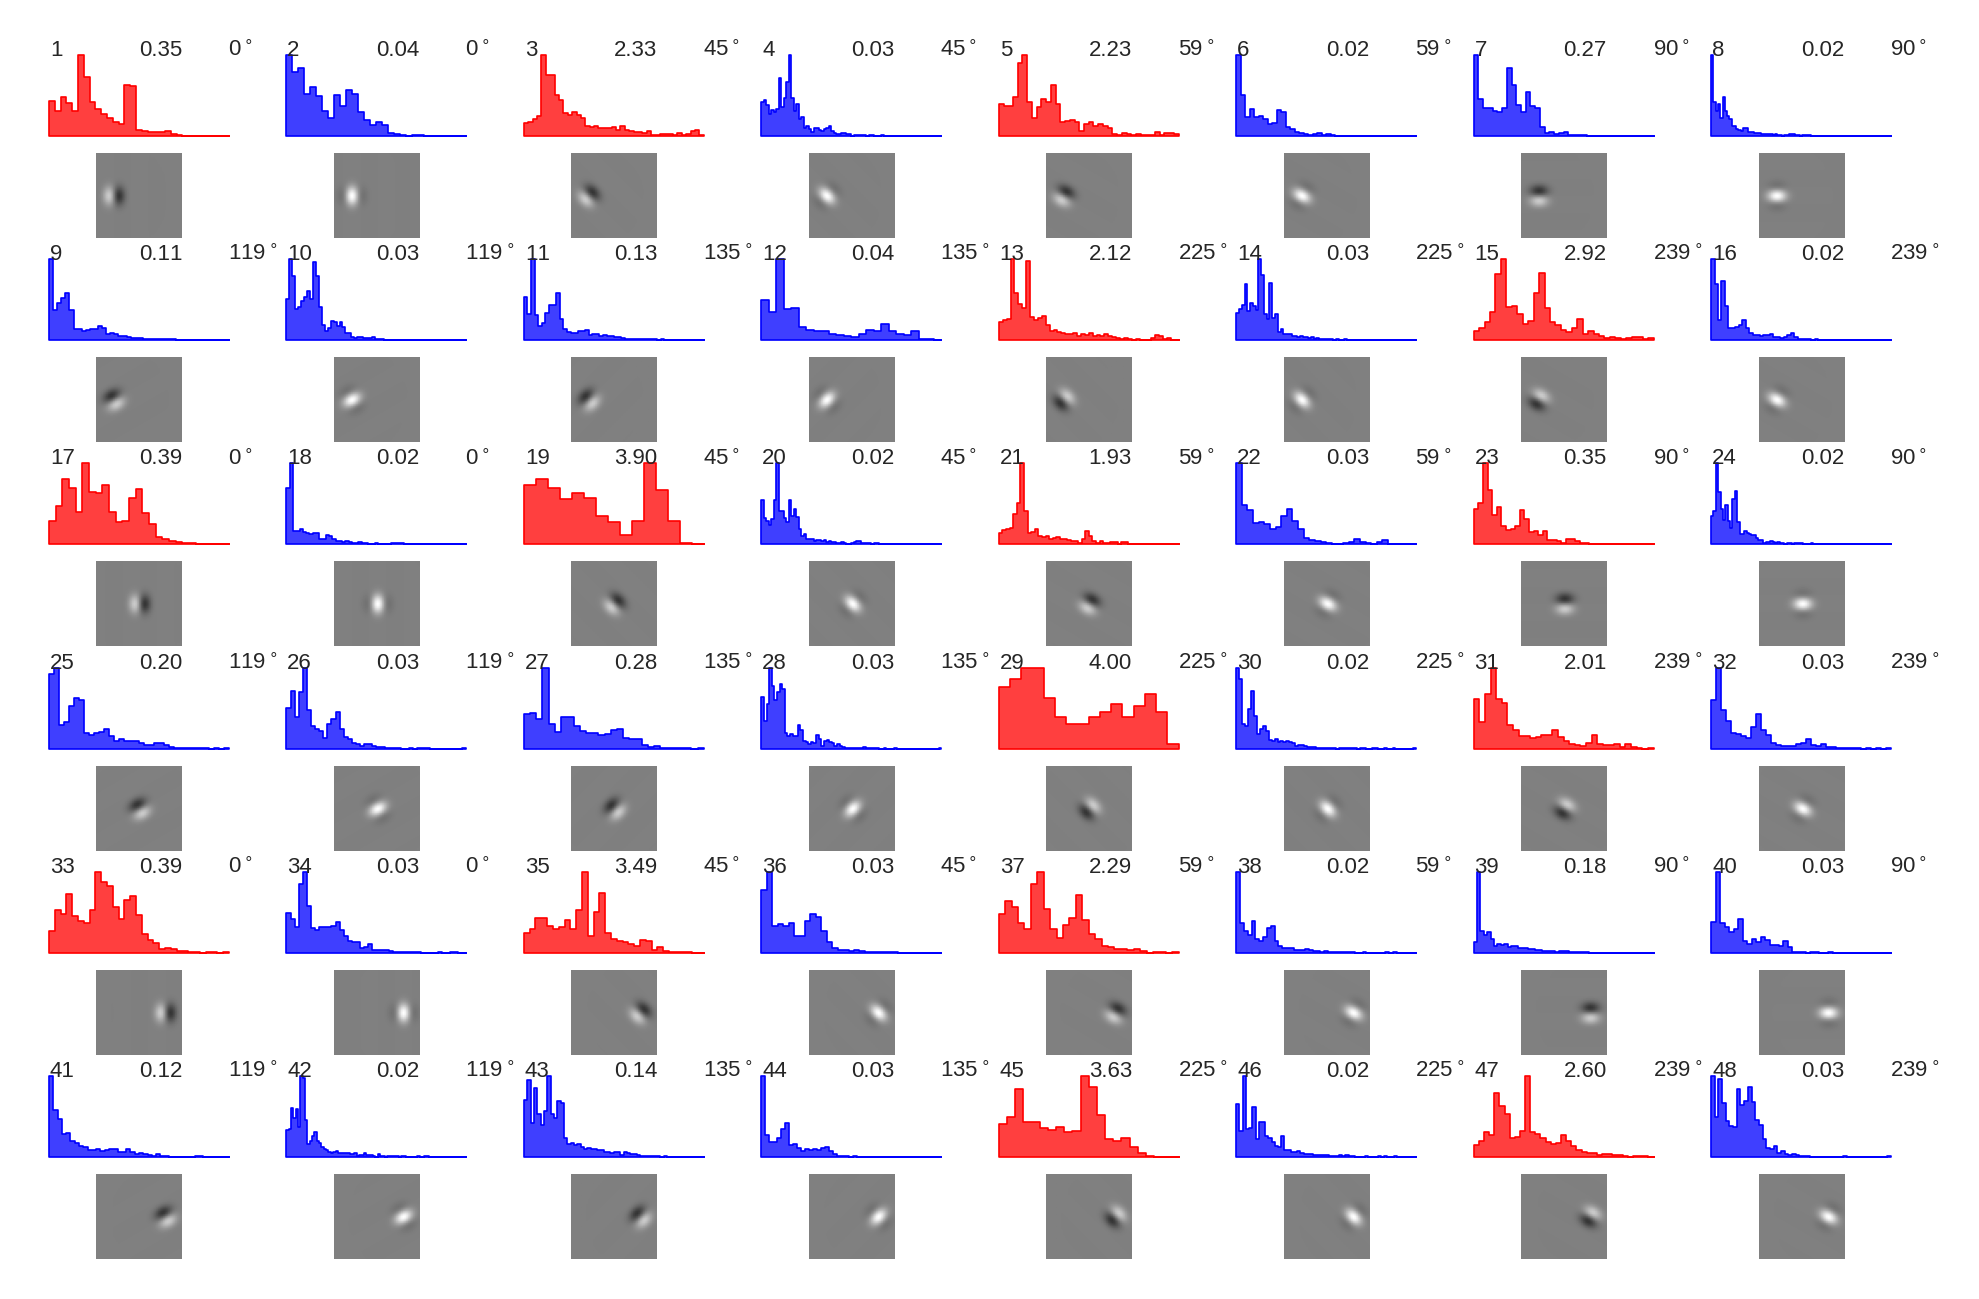

In [55]:
plot_samples(circle_center_trace, gabor_set.images(), orientations)

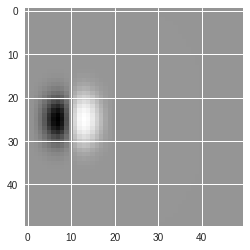

In [51]:
plt.imshow(gabor_set.images()[0])

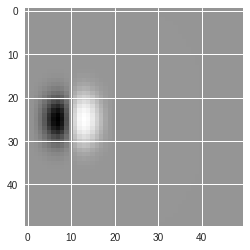

In [50]:
plt.imshow(torch.tensor(gabor_set.images()).permute(1, 2, 0)[:,:,0].numpy())